# 4- Trying the models

Classifier: SVM (linear), RF

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cognitive_models.preprocessing as cwpre
import cognitive_models.features as cwfeat
import cognitive_models.interpolate as cwinterp
import cognitive_models.pupil_utils as cwpupil
from importlib import reload
reload(cwpupil)
reload(cwinterp)
reload(cwpre)
reload(cwfeat)

COLET_DATASET_DIR = Path(cwpre.__file__).parents[2] / "datasets" / "COLET_CSV"
PARTICIPANTS = list(range(1, 48)) # Participants 1 to 10
PARTICIPANTS.remove(6) # Bad data
EXPERIMENTS = [1,2,3,4]

### A. Getting all the needed features

In [2]:
# 1- Load all required data
all_eye_data = cwpre.load_colet_data(COLET_DATASET_DIR, PARTICIPANTS, EXPERIMENTS)

print(f"Loaded eye-tracking data for {len(PARTICIPANTS)} participants and {len(EXPERIMENTS)} experiments. Total records: {len(all_eye_data)}")

There are 1 non matching timestamp_sec within the limits
Final merged dataset has 8184 records at 240 Hz
Final merged and resampled dataset has 2028 records at 60 Hz
There are 1 non matching timestamp_sec within the limits
Final merged dataset has 6866 records at 240 Hz
Final merged and resampled dataset has 1709 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 17301 records at 240 Hz
Final merged and resampled dataset has 4285 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 9246 records at 240 Hz
Final merged and resampled dataset has 2290 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 10159 records at 240 Hz
Final merged and resampled dataset has 2505 records at 60 Hz
There are 0 non matching timestamp_sec within the limits
Final merged dataset has 7113 records at 240 Hz
Final merged and resampled dataset has 1769 records at 60 Hz
Th

In [3]:
# Lets check integrity of the data
all_eye_data.columns
all_eye_data.groupby(['subject_id', 'task_id'])['cl_class'].value_counts().sort_index().head()

subject_id  task_id  cl_class
1           1        low         2028
            2        medium      1709
            3        high        4285
            4        medium      2290
2           1        low         2505
Name: count, dtype: int64

In [4]:
import tqdm
all_eye_data_grouped = all_eye_data.groupby(['subject_id', 'task_id'])
# Extract all window features
Fs = 60
WINDOW_N = 512
WINDOW_STEP = 64
SKIP_EDGE_SAMPLES = Fs # first & last 2 seconds are discarded

features_df = pd.DataFrame()
for (subject_id, task_id), group_df in tqdm.tqdm(all_eye_data_grouped, desc="Extracting features"):
    feature_rows = []
    # Discard edge samples
    group_df = group_df.iloc[SKIP_EDGE_SAMPLES:-SKIP_EDGE_SAMPLES].sort_values('timestamp_sec')
    
    # Extract features in sliding windows
    for start in range(WINDOW_N, len(group_df), WINDOW_STEP):
        window_df = group_df.iloc[start - WINDOW_N:start].reset_index(drop=True)
        window_df, blink_df = cwpre.preprocess_colet_data(window_df, verbose=False) # Add derived columns
        features = cwfeat.extract_window_features(window_df, blink_df, ivt_threshold=45, min_fixation_duration=55, verbose=False)
        features['subject_id'] = subject_id
        features['task_id'] = task_id
        features['cl_class'] = window_df['cl_class'].iloc[0] # Class is the same for a given task
        feature_rows.append(features)
    
    features_df = pd.concat([features_df, pd.DataFrame(feature_rows)], ignore_index=True)

print(f"Extracted features for {len(features_df)} windows.")

Extracting features: 100%|██████████| 76/76 [06:15<00:00,  4.95s/it]

Extracted features for 2766 windows.


In [ ]:
# Check what is the issue with the NaNs
features_df[features_df.isna().any(axis=1)].head()

,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_std,saccades_count,saccades_peak_velocity_mean,saccades_amplitude_mean,saccades_amplitude_max,saccades_amplitude_min,...,saccades_duration_mean,saccades_duration_max,saccades_duration_min,saccades_duration_std,blinks_count,blinks_duration_mean,pupil_lhipa,subject_id,task_id,cl_class
1642,0,NaN,NaN,NaN,NaN,7,966.215551,70.546382,150.437726,0.009972,...,957.334286,3067.28,266.72,958.240222,8,0.154197,4.343554,13,3,medium


In [6]:
from sklearn import preprocessing
# z-normalize features
features_df_transformed = features_df.copy()
features_df_transformed.dropna(inplace=True) # Drop rows with NaNs for now
feature_cols = [col for col in features_df.columns if col not in ['subject_id', 'task_id', 'cl_class']]

features_df_transformed.describe()

,fixations_count,fixations_duration_mean,fixations_duration_max,fixations_duration_min,fixations_duration_std,saccades_count,saccades_peak_velocity_mean,saccades_amplitude_mean,saccades_amplitude_max,saccades_amplitude_min,saccades_amplitude_std,saccades_duration_mean,saccades_duration_max,saccades_duration_min,saccades_duration_std,blinks_count,blinks_duration_mean,pupil_lhipa,subject_id,task_id
count,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000
mean,15.718264,376.711827,1281.377382,79.087544,353.784220,16.870524,158.758745,1.842410,11.229206,0.050464,3.033626,78.356888,342.401197,17.333183,90.013140,2.220615,0.098563,4.690512,10.740687,2.789150
std,5.382595,183.479073,708.023962,43.970230,251.147581,4.794988,89.465330,3.540804,26.023134,0.632056,7.020152,85.681569,422.267033,15.474020,125.472919,2.522792,0.073115,0.341437,5.520684,1.071954
min,1.000000,78.587143,83.350000,50.010000,0.000000,2.000000,58.241446,0.268942,0.965858,0.000000,0.367043,20.004000,33.340000,0.000000,7.350779,0.000000,0.000000,2.934834,1.000000,1.000000
25%,12.000000,274.692609,816.830000,50.010000,212.260798,13.000000,101.374941,0.937383,2.206561,0.001932,0.723680,44.453333,100.020000,16.670000,25.404724,0.000000,0.000000,4.460947,5.000000,2.000000
50%,16.000000,340.068000,1116.890000,66.680000,297.179314,17.000000,134.205434,1.118720,2.539412,0.015302,0.824658,55.566667,183.370000,16.670000,43.545184,1.000000,0.116690,4.695734,11.000000,3.000000
75%,20.000000,428.517059,1583.650000,83.350000,424.290708,20.000000,184.929807,1.367874,4.773510,0.043154,1.329756,81.497778,400.080000,16.670000,100.904745,3.000000,0.153156,4.930521,15.000000,4.000000
max,33.000000,4150.830000,7834.900000,716.810000,4856.437657,32.000000,969.467997,82.757542,173.251822,32.781253,62.307483,1453.624000,4050.810000,483.430000,1740.694459,16.000000,0.283390,5.752274,20.000000,4.000000


In [12]:
from sklearn.model_selection import train_test_split
from sklearn import svm, pipeline

features_df_transformed['labels'] = features_df_transformed['cl_class'].map({'low': 0, 'medium': 1, 'high': 2})

X = features_df_transformed[feature_cols].values
y = features_df_transformed['labels'].values

scaler = preprocessing.StandardScaler()
# scaler = preprocessing.MinMaxScaler()
scaler.fit(X)

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)
# Split train validation set from train set
train_x, val_x, train_y, val_y = train_test_split(train_x, train_y, test_size=0.25, random_state=42)

print(f"Training set size: {len(train_x)}, Validation set size: {len(val_x)}, Test set size: {len(test_x)}")

train_x_transformed = scaler.transform(train_x)
val_x_transformed = scaler.transform(val_x)
model = svm.LinearSVC()
model.fit(train_x_transformed, train_y)
train_acc = model.score(train_x_transformed, train_y)
val_acc = model.score(val_x_transformed, val_y)
print(f"Train Accuracy: {train_acc:.2f}, Validation Accuracy: {val_acc:.2f}")

Training set size: 1659, Validation set size: 553, Test set size: 553
Train Accuracy: 0.56, Validation Accuracy: 0.59


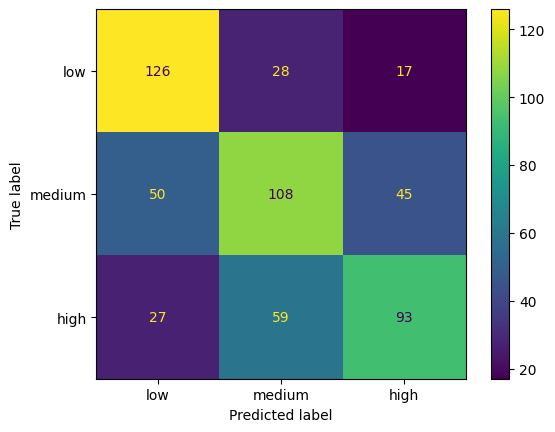

In [13]:
# Lets show the confusion matrix for the 3 classes (on validation set)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

val_y_pred = model.predict(val_x_transformed)
cm = confusion_matrix(val_y, val_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['low', 'medium', 'high'])
disp.plot()